# 🛒 Retail Sales EDA Project

## Objective

This project performs Exploratory Data Analysis (EDA) on a retail sales dataset to uncover insights related to sales performance, customer behavior, and operational efficiency.

## Import all the important libraries required for the analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from urllib.request import urlretrieve
import os 

## Load the analysis dataset

In [2]:
data = pd.read_csv('Project Sales Dataset.csv')

In [3]:
data

,Date,Region,Product,Quantity,UnitPrice,StoreLocation,CustomerType,Discount,Salesperson,TotalPrice,...,Returned,OrderID,CustomerName,ShippingCost,OrderDate,DeliveryDate,RegionManager,Revenue,DeliveryDays,ShippingBuckets
0,2/23/2023,East,Laptop,14,163.60,Store B,Wholesale,0.00,Eva,2290.400,...,0,REG100000,Cust 6583,43.34,2/23/2023,2/27/2023,Eric,2290.400,4,High
1,12/19/2024,South,Phone,1,544.01,Store A,Retail,0.00,Alice,544.010,...,0,REG100001,Cust 2144,5.30,12/19/2024,12/28/2024,Sophie,544.010,9,Low
2,05-10-2023,North,Desk,14,346.18,Store B,Wholesale,0.10,Alice,4361.868,...,0,REG100002,Cust 5998,20.46,05-10-2023,5/19/2023,Ryan,4361.868,9,Medium
3,2/26/2025,Central,Chair,18,384.82,Store A,Wholesale,0.15,Frank,5887.746,...,0,REG100003,Cust 7136,27.95,2/26/2025,03-02-2025,Cameron,5887.746,4,Medium
4,6/24/2023,East,Desk,18,237.76,Store C,Retail,0.00,Carlos,4279.680,...,0,REG100004,Cust 6506,5.73,6/24/2023,6/27/2023,Eric,4279.680,3,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1125,2/17/2025,West,Desk,13,134.56,Store D,Retail,0.05,Carlos,1661.816,...,0,REG101495,Cust 5227,35.63,2/17/2025,2/22/2025,Wendy,1661.816,5,Upper Medium
1126,01-11-2024,South,Chair,18,209.75,Store C,Wholesale,0.15,Frank,3209.175,...,0,REG101496,Cust 5559,45.93,01-11-2024,1/17/2024,Sophie,3209.175,6,High
1127,7/27/2024,East,Desk,1,272.50,Store A,Wholesale,0.00,Eva,272.500,...,0,REG101497,Cust 8981,35.56,7/27/2024,08-03-2024,Eric,272.500,7,Upper Medium
1128,12-03-2024,Central,Monitor,14,262.67,Store A,Retail,0.05,Carlos,3493.511,...,0,REG101498,Cust 1824,24.53,12-03-2024,12-10-2024,Cameron,3493.511,7,Medium


## Columns in the dataset

In [4]:
data.columns

Index(['Date', 'Region', 'Product', 'Quantity', 'UnitPrice', 'StoreLocation',
       'CustomerType', 'Discount', 'Salesperson', 'TotalPrice',
       'PaymentMethod', 'Promotion', 'Returned', 'OrderID', 'CustomerName',
       'ShippingCost', 'OrderDate', 'DeliveryDate', 'RegionManager', 'Revenue',
       'DeliveryDays', 'ShippingBuckets'],
      dtype='object')

## Brief summary of the dataset

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1130 entries, 0 to 1129
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             1130 non-null   object 
 1   Region           1130 non-null   object 
 2   Product          1130 non-null   object 
 3   Quantity         1130 non-null   int64  
 4   UnitPrice        1130 non-null   float64
 5   StoreLocation    1130 non-null   object 
 6   CustomerType     1130 non-null   object 
 7   Discount         1130 non-null   float64
 8   Salesperson      1130 non-null   object 
 9   TotalPrice       1130 non-null   float64
 10  PaymentMethod    1130 non-null   object 
 11  Promotion        1130 non-null   object 
 12  Returned         1130 non-null   int64  
 13  OrderID          1130 non-null   object 
 14  CustomerName     1130 non-null   object 
 15  ShippingCost     1130 non-null   float64
 16  OrderDate        1130 non-null   object 
 17  DeliveryDate  

## Statistical summary of the dataset

In [6]:
data.describe()

,Quantity,UnitPrice,Discount,TotalPrice,Returned,ShippingCost,Revenue,DeliveryDays
count,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000,1130.000000
mean,10.468142,296.827832,0.072655,2925.438635,0.247788,27.290434,2184.834627,6.024779
std,5.820564,167.276614,0.056311,2530.620515,0.431919,13.137328,2512.930043,2.551386
min,1.000000,5.520000,0.000000,11.142000,0.000000,5.010000,0.000000,2.000000
25%,5.000000,152.772500,0.000000,897.102750,0.000000,16.407500,28.365875,4.000000
50%,11.000000,293.390000,0.050000,2151.047500,0.000000,27.075000,1282.205000,6.000000
75%,16.000000,441.642500,0.100000,4475.559500,0.000000,38.197500,3506.706500,8.000000
max,20.000000,599.720000,0.150000,11077.000000,1.000000,49.980000,11077.000000,10.000000


## Data Preprocessing
- Converted date columns to datetime format
- Extracted month and year for time-based analysis

In [7]:
data['Date'] =  pd.to_datetime(data.Date)
data['OrderDate'] =  pd.to_datetime(data.OrderDate)
data['DeliveryDate'] =  pd.to_datetime(data.DeliveryDate)

Extract the order month and year from the Order date

In [8]:
data['sales_month'] = pd.DatetimeIndex(data.OrderDate).month
data['sales_year'] = pd.DatetimeIndex(data.OrderDate).year

In [9]:
data[['OrderDate','sales_month','sales_year']].head()

,OrderDate,sales_month,sales_year
0,2023-02-23,2,2023
1,2024-12-19,12,2024
2,2023-05-10,5,2023
3,2025-02-26,2,2025
4,2023-06-24,6,2023


## 📊 1. Overall Business Performance

* What is the total revenue generated?

* What is the average order value?

* How many orders are there?

* What is the total quantity sold?

In [10]:
# What is the total revenue generated?
total_revenue = data['Revenue'].sum()
print(f"The total revenue generated is ${total_revenue:.2f}")

The total revenue generated is $2468863.13


The business generates strong overall revenue, indicating healthy sales performance.

In [11]:
# What is the average order value?
total_orders = data['OrderID'].count()
avg_order_value = total_revenue / total_orders
print(f"The average order value is {avg_order_value:.2f}")

The average order value is 2184.83


The average order value suggests moderate spending per transaction.

In [12]:
# How many orders are there?
total_orders = data['OrderID'].count()
print(f"The total orders is {total_orders}")

The total orders is 1130


A substantial number of orders indicates consistent customer activity.

In [13]:
# What is the total quantity sold?
total_quantity = data['Quantity'].sum()
print(f"The total quantity sold is {total_quantity}")

The total quantity sold is 11829


High total quantity sold reflects strong product demand.

## 📦 2. Product Analysis

* Which products generate the highest revenue?

* Which products are sold the most (quantity)?

* Are there products with high sales but low revenue?

In [14]:
# Which products generate the highest revenue?
products_by_revenue = data.groupby('Product')[['Revenue']].sum()

In [15]:
products_by_revenue.sort_values('Revenue',ascending=False)

,Revenue
Product,
Tablet,406446.2150
Printer,398275.9635
Laptop,363709.2095
Monitor,362121.2945
Chair,356795.0380
Desk,293398.7415
Phone,288116.6670


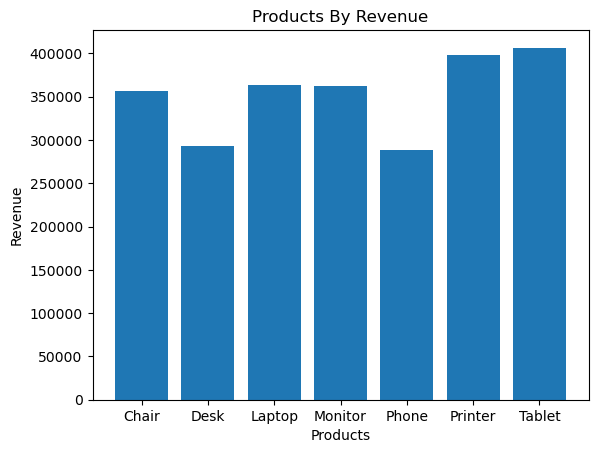

In [16]:
plt.title("Products By Revenue")
plt.bar(products_by_revenue.index, products_by_revenue.Revenue)
plt.xlabel('Products')
plt.ylabel('Revenue');

Tablet, Laptop, and Monitor generate the highest revenue.

In [17]:
# Which products are sold the most (quantity)?
products_by_quantity = data.groupby('Product')[['Quantity']].sum()

In [18]:
products_by_quantity.sort_values('Quantity',ascending=False)

,Quantity
Product,
Tablet,2084
Laptop,1826
Monitor,1816
Printer,1703
Chair,1584
Phone,1460
Desk,1356


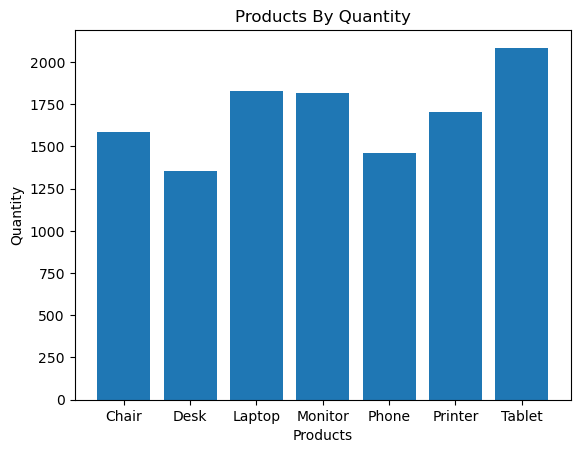

In [19]:
plt.title("Products By Quantity")
plt.bar(products_by_quantity.index, products_by_quantity.Quantity,)
plt.xlabel("Products")
plt.ylabel("Quantity");

Tablet is the most sold product in terms of quantity.

In [20]:
# Are there products with high sales but low revenue?
products  = data.groupby('Product')[['Quantity', 'Revenue']].sum()

In [21]:
products.sort_values('Quantity',ascending=False)
products.sort_values('Revenue',ascending=False)

,Quantity,Revenue
Product,,
Tablet,2084,406446.2150
Printer,1703,398275.9635
Laptop,1826,363709.2095
Monitor,1816,362121.2945
Chair,1584,356795.0380
Desk,1356,293398.7415
Phone,1460,288116.6670


In [22]:
sns.set_style('darkgrid')

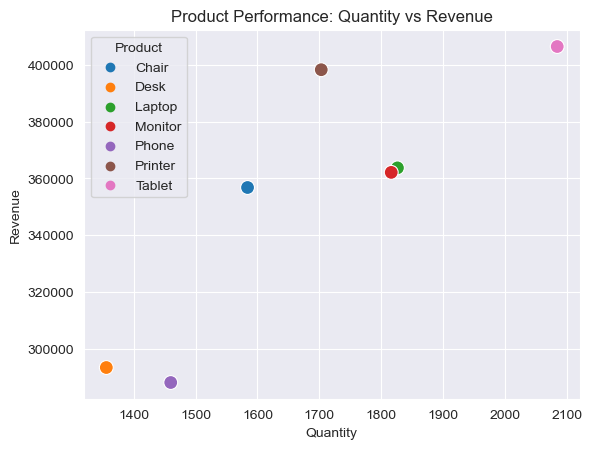

In [23]:
plt.title("Product Performance: Quantity vs Revenue")
sns.scatterplot(x='Quantity',y='Revenue',hue=products.index, data=products, s=100);

Products like Phone and Desk have relatively high sales but lower revenue, indicating lower pricing or margins.

## 📊 Final Insights

Tablet, Laptop, and Monitor are the top-performing products in terms of both revenue and quantity sold. However, products like Phone and Desk show relatively lower revenue despite moderate sales volume, indicating lower pricing or higher discounts.

## 🌍 3. Regional Analysis

* Which region has the highest sales/revenue?

* Which region has the highest returns?

* Are some regions underperforming?

In [24]:
# Which region has the highest sales/revenue?

region_by_revenue = data.groupby('Region')[['Revenue']].sum()

In [25]:
region_by_revenue.sort_values('Revenue', ascending=False)

,Revenue
Region,
North,544363.9095
East,510792.0285
South,477384.0295
West,475712.4720
Central,460610.6895


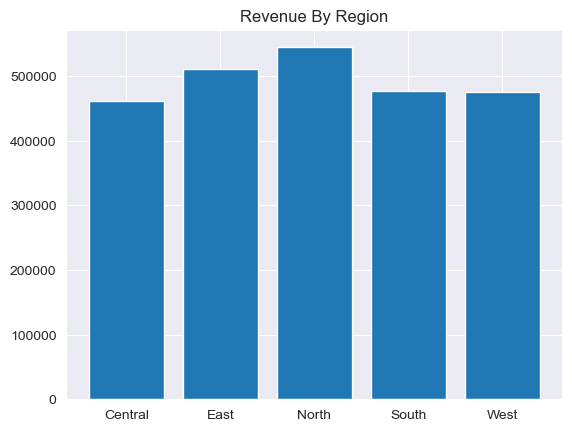

In [26]:
plt.title("Revenue By Region")
plt.bar(region_by_revenue.index,region_by_revenue.Revenue);

North region generates the highest revenue.

In [27]:
# Which region has the highest returns?
returned_data = data.groupby('Region')[['Returned']].sum()

In [28]:
returned_data.sort_values('Returned',ascending=False)

,Returned
Region,
South,63
West,62
East,57
North,52
Central,46


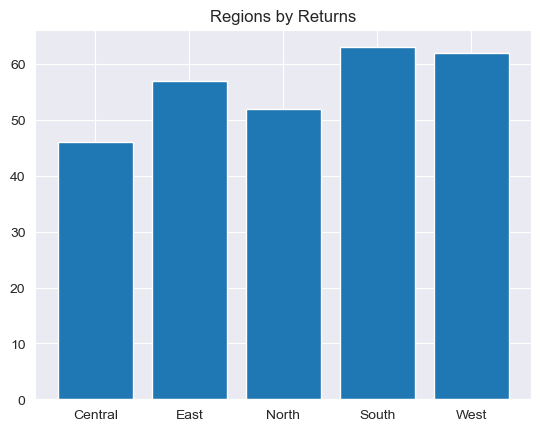

In [29]:
plt.title("Regions by Returns")
plt.bar(returned_data.index,returned_data.Returned);

South and West regions have the highest number of returns.

In [30]:
# Are some regions underperforming?
regions = data.groupby('Region')[['Revenue','Returned']].sum()

In [31]:
regions

,Revenue,Returned
Region,,
Central,460610.6895,46
East,510792.0285,57
North,544363.9095,52
South,477384.0295,63
West,475712.4720,62


<AxesSubplot:title={'center':'Revenue vs Returns by Region'}, xlabel='Returned', ylabel='Revenue'>

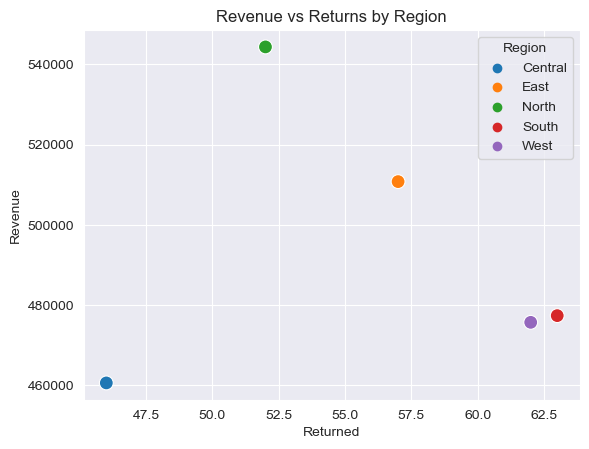

In [32]:
plt.title("Revenue vs Returns by Region")
sns.scatterplot(x="Returned", y="Revenue",hue=regions.index,s=100,data=regions)

Central region shows comparatively lower revenue and activity.

## 📊 Final Insights

The North region generates the highest revenue, making it the top-performing region. In contrast, South and West regions exhibit higher return counts despite moderate revenue, suggesting potential operational or product-related issues.

## 👥 4. Customer Behavior

* Which customer type contributes more revenue?

* Do different customer types have different buying patterns?

* Which customer type has more returns?

In [33]:
# Which customer type contributes more revenue?
customer_by_revenue = data.groupby('CustomerType')[['Revenue']].sum()

In [34]:
customer_by_revenue.sort_values('Revenue',ascending=False)

,Revenue
CustomerType,
Wholesale,1.246446e+06
Retail,1.222417e+06


<BarContainer object of 2 artists>

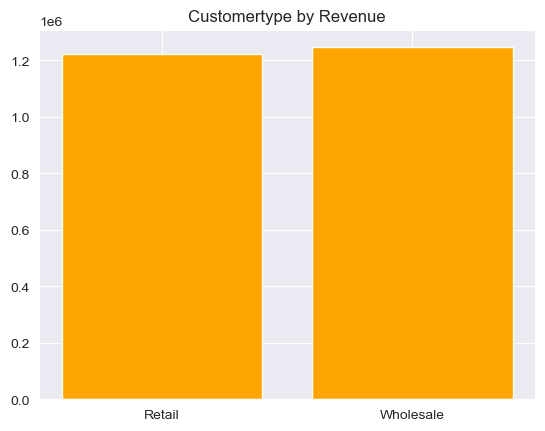

In [35]:
plt.title("Customertype by Revenue")
plt.bar(customer_by_revenue.index,customer_by_revenue.Revenue,color='orange')

Wholesale customers contribute slightly higher revenue than retail customers.

In [36]:
# Which customer type has more returns?
customer_by_returns = data.groupby('CustomerType')[['Returned']].sum()

In [37]:
customer_by_returns.sort_values('Returned',ascending=False)

,Returned
CustomerType,
Wholesale,146
Retail,134


<BarContainer object of 2 artists>

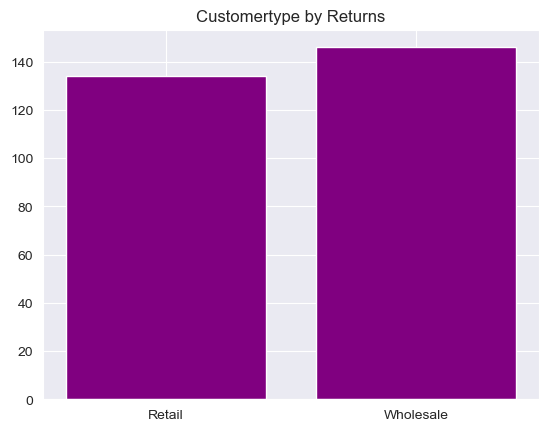

In [38]:
plt.title("Customertype by Returns")
plt.bar(customer_by_returns.index,customer_by_returns.Returned,color='purple')

Wholesale customers have higher return counts compared to retail customers.

In [39]:
# Do different customer types have different buying patterns?
customer_by_quantity = data.groupby('CustomerType')[['Quantity']].sum()

In [40]:
customer_by_quantity.sort_values('Quantity',ascending=False)

,Quantity
CustomerType,
Wholesale,6136
Retail,5693


<BarContainer object of 2 artists>

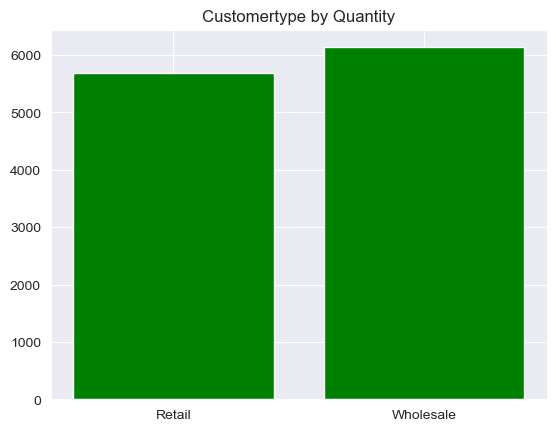

In [41]:
plt.title("Customertype by Quantity")
plt.bar(customer_by_quantity.index,customer_by_quantity.Quantity,color='green')

In [42]:
# Do different customer types have different buying patterns?
customer_by_products = data.groupby(['Product','CustomerType'])[['Quantity']].sum()

In [43]:
pivot_data = customer_by_products.unstack()

In [44]:
pivot_data.columns = pivot_data.columns.droplevel(0)

In [45]:
print(pivot_data.columns)

Index(['Retail', 'Wholesale'], dtype='object', name='CustomerType')


In [46]:
pivot_data['Total'] = pivot_data['Retail'] + pivot_data['Wholesale']
pivot_data = pivot_data.sort_values('Total', ascending=False)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'Tablet'),
  Text(1, 0, 'Laptop'),
  Text(2, 0, 'Monitor'),
  Text(3, 0, 'Printer'),
  Text(4, 0, 'Chair'),
  Text(5, 0, 'Phone'),
  Text(6, 0, 'Desk')])

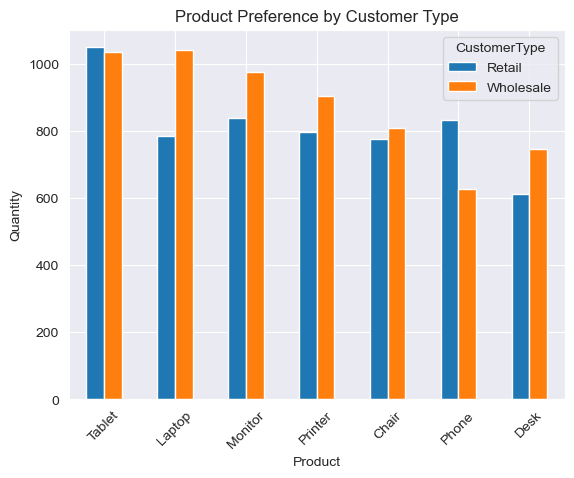

In [47]:
pivot_data[['Retail','Wholesale']].plot(kind='bar')
plt.title("Product Preference by Customer Type")
plt.ylabel("Quantity")
plt.xlabel("Product")
plt.xticks(rotation=45)

Wholesale customers purchase in larger quantities, indicating bulk buying behavior.

## 📊 Final Insights

Wholesale customers contribute slightly higher revenue and purchase larger quantities compared to retail customers, indicating bulk buying behavior. However, they also show higher return counts, which may be associated with bulk purchasing risks.

## 💸 5. Discount & Promotion Impact

* Does higher discount lead to higher sales?

* Are promotions actually increasing revenue?

* Do discounts increase returns?

In [48]:
#  Does higher discount lead to higher sales?
discount_pivot =data.groupby('Discount')[['Quantity']].mean()

In [49]:
discount_pivot 

,Quantity
Discount,
0.00,10.302932
0.05,10.652015
0.10,10.256228
0.15,10.691450


<AxesSubplot:xlabel='Discount', ylabel='Quantity'>

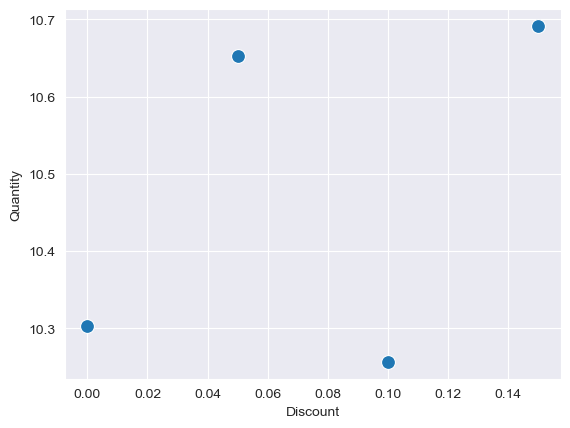

In [50]:
sns.scatterplot(x=discount_pivot.index,y=discount_pivot.Quantity,s=100)

Discounts do not show a consistent impact on sales volume.

In [51]:
# Are promotions actually increasing revenue?
promotions_pivot = data.groupby('Promotion')[['Revenue']].sum()

In [52]:
promotions_pivot.sort_values('Revenue',ascending=False)

,Revenue
Promotion,
FREESHIP,934846.8030
WINTER15,795994.5705
SAVE10,738021.7555


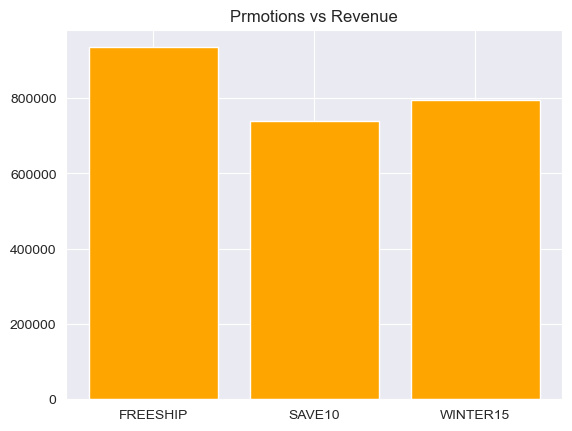

In [53]:
plt.title("Prmotions vs Revenue")
plt.bar(promotions_pivot.index,promotions_pivot.Revenue,color='orange');

FREESHIP promotion generates the highest revenue among all promotions.

In [54]:
# Do discounts increase returns?
discount_returns = data.groupby('Discount')[['Returned']].sum()

In [55]:
discount_returns.sort_values(by=['Discount','Returned'],ascending=False)

,Returned
Discount,
0.15,79
0.10,59
0.05,65
0.00,77


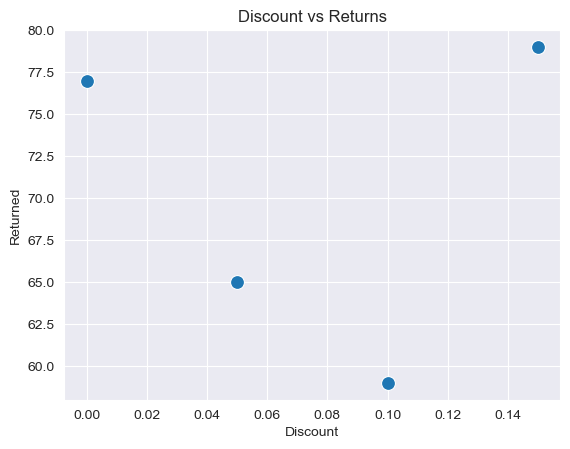

In [56]:
plt.title("Discount vs Returns")
sns.scatterplot(x=discount_returns.index,y=discount_returns.Returned,s=100);

There is no clear relationship between discount levels and return counts.

## 📊 Final Insights

Discounts do not show a strong or consistent impact on sales volume. While certain discount levels slightly increase sales, the overall trend is inconsistent, indicating that discounts alone are not a major driver of sales.

## 🚚 6. Delivery & Shipping Analysis

* What is the average delivery time?

* Do longer delivery times lead to more returns?

* Which shipping bucket is most common?

* Does higher shipping cost affect revenue?

In [57]:
# What is the average delivery time?
avg_delivery_time = data.DeliveryDays.mean()
print(f"The average delivery time is {avg_delivery_time:.2f}")

The average delivery time is 6.02


The average delivery time is approximately 6 days.

In [58]:
# Do longer delivery times lead to more returns?
delivery_data = data.groupby('DeliveryDays')[['Returned']].mean()

In [59]:
delivery_data.sort_values('Returned',ascending=False)

,Returned
DeliveryDays,
6,0.330357
7,0.275362
10,0.273504
9,0.246154
3,0.242424
4,0.238806
8,0.225564
2,0.223214
5,0.180328


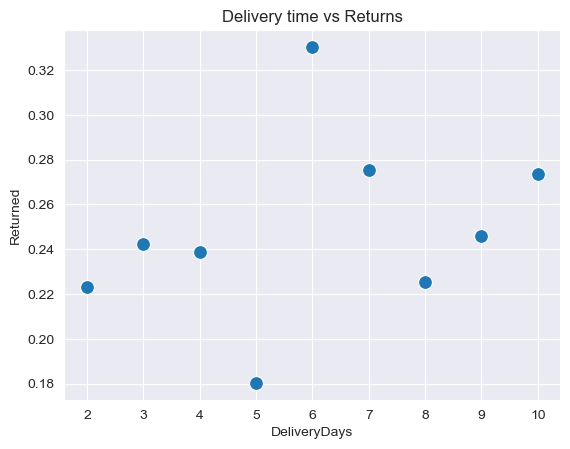

In [60]:
plt.title("Delivery time vs Returns")
sns.scatterplot(x=delivery_data.index,y=delivery_data.Returned,s=100);

Returns slightly increase with delivery time up to a point but show no consistent trend.

In [61]:
# Which shipping bucket is most common?
common_shippingBucket = data.ShippingBuckets.mode()
common_shippingBucket[0]

'Upper Medium'

Upper Medium is the most frequently used shipping bucket.

In [62]:
# Does higher shipping cost affect revenue?
shippingcost_pivot = data.groupby('ShippingBuckets')[['Revenue']].sum()

In [63]:
shippingcost_pivot.sort_values('Revenue',ascending=False)

,Revenue
ShippingBuckets,
Upper Medium,582384.7440
Medium,555907.6325
Lower Medium,548986.0970
High,497384.5555
Low,284200.1000


<BarContainer object of 5 artists>

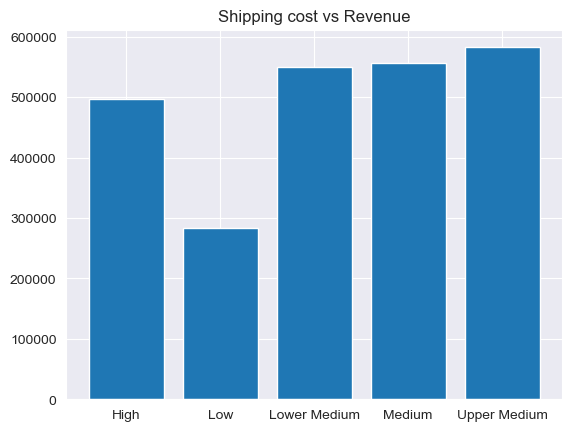

In [64]:
plt.title('Shipping cost vs Revenue')
plt.bar(shippingcost_pivot.index,shippingcost_pivot.Revenue)

Mid-range shipping costs generate higher revenue compared to very low or high costs.

## 📊 Final Insights

The FREESHIP promotion generates the highest revenue, outperforming percentage-based promotions like SAVE10 and WINTER15. This suggests that customers respond more positively to free shipping incentives.

## 🔁 7. Returns Analysis

* What percentage of orders are returned?

* Which products are returned the most?

* Are returns higher in certain regions or customer types?

In [65]:
total_orders

1130

In [66]:
# What percentage of orders are returned?
returned_orders = data[['Returned']].sum()

In [67]:
returned_percent = returned_orders[0] * 100 / total_orders
print(f"The percentage of orders that were returned out of {total_orders} is {returned_percent:.2f}%")

The percentage of orders that were returned out of 1130 is 24.78%


Approximately 24.78% of orders are returned.

In [68]:
# Are returns higher in certain regions or customer types?
return_data = data.groupby(['Region','CustomerType'])[['Returned']].sum()

In [69]:
return_pivot = return_data.unstack()

In [70]:
return_pivot.columns = return_pivot.columns.droplevel(0)

In [71]:
return_pivot.sort_values(by=['Retail','Wholesale'],ascending=False)

CustomerType,Retail,Wholesale
Region,,
South,31,32
North,30,22
West,27,35
East,27,30
Central,19,27


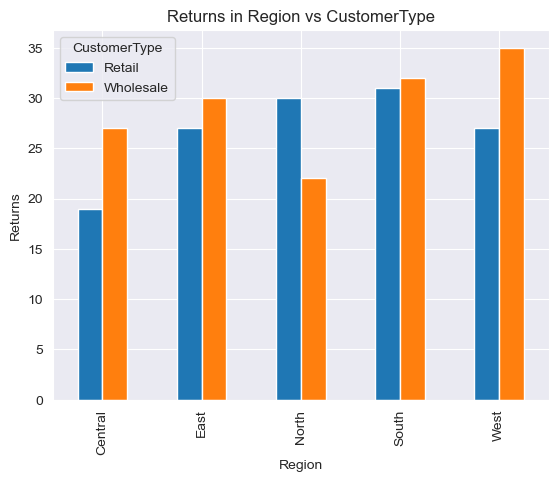

In [72]:
return_pivot[['Retail','Wholesale']].plot(kind='bar');
plt.title("Returns in Region vs CustomerType")
plt.xlabel('Region')
plt.ylabel('Returns');

Returns are higher in South and West regions and among wholesale customers.

In [73]:
# Which products are returned the most?
returned_products = data.groupby('Product')[['Returned']].sum()

In [74]:
returned_products.sort_values('Returned',ascending=False)

,Returned
Product,
Tablet,50
Monitor,48
Laptop,42
Chair,40
Phone,38
Desk,33
Printer,29


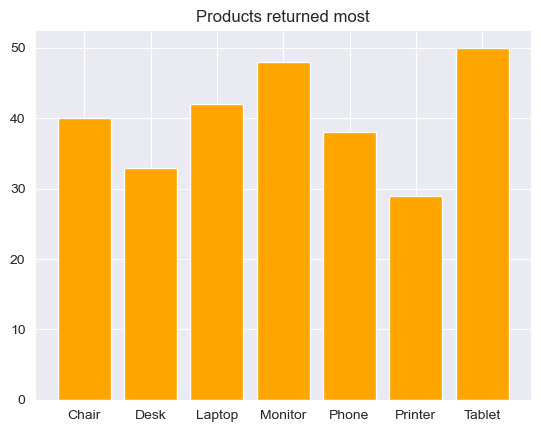

In [75]:
plt.title('Products returned most')
plt.bar(returned_products.index,returned_products.Returned,color='orange');

Certain high-demand products also show higher return counts.

## 📊 Final Insights

The average delivery time is approximately 6 days. There is no strong relationship between delivery time and returns, although returns tend to peak around 6–7 days. The most commonly used shipping bucket is Upper Medium, and mid-range shipping costs generate higher revenue compared to very low or very high shipping costs

## 💳 8. Payment Method Analysis

* Which payment method is most used?

* Does payment method affect:

   * revenue?

   * returns?

In [76]:
# Which payment method is most used?
common_payment = data['PaymentMethod'].mode()

In [77]:
print(f"The most commonly used payment methods are {common_payment[0]} and {common_payment[1]}")

The most commonly used payment methods are Cash and Online


In [78]:
# Does payment method affect: Revenue and Returns
payment_data = data.groupby('PaymentMethod')[['Revenue','Returned']].sum()

In [79]:
payment_data.sort_values(by=['Revenue','Returned'],ascending=False)

,Revenue,Returned
PaymentMethod,,
Online,551446.9190,53
Cash,537055.6860,72
Gift Card,489273.1865,50
Credit Card,487375.6695,46
Debit Card,403711.6680,59


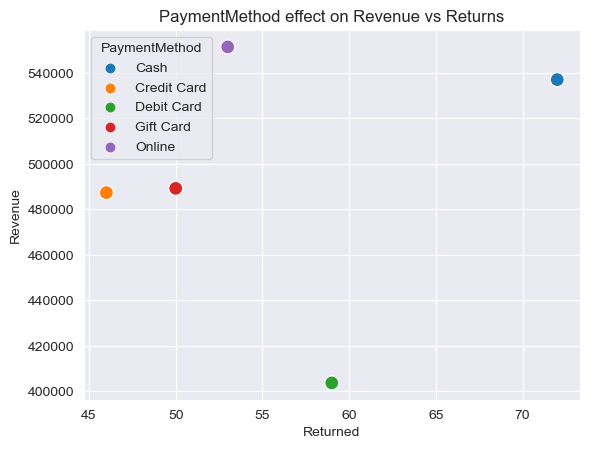

In [80]:
plt.title('PaymentMethod effect on Revenue vs Returns')
sns.scatterplot(x=payment_data.Returned,y=payment_data.Revenue,hue=payment_data.index,s=100);

Cash payments are associated with higher return counts.

## 📊 Final Insights

Cash and Online are the most commonly used payment methods. Online payments generate the highest revenue, while Cash transactions are associated with the highest number of returns. This indicates that payment method may influence both purchasing and return behavior.

## ⏳ 9. Time-Based Analysis

* How do sales vary by month?

* Are there any trends or seasonality?

* Are returns increasing over time?


In [81]:
# How do sales vary by month?
monthly_sales = data.groupby('sales_month')[['Quantity']].sum()

In [82]:
monthly_sales

,Quantity
sales_month,
1,1389
2,1270
3,1453
4,1077
5,1106
6,1113
7,737
8,809
9,764


Text(0, 0.5, 'Quantity')

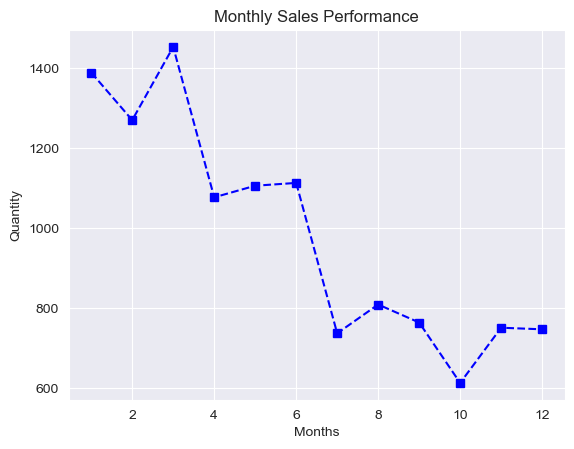

In [83]:
plt.title("Monthly Sales Performance")
plt.plot(monthly_sales,'s--b')
plt.xlabel("Months")
plt.ylabel("Quantity")

Sales peak in the early months and decline during mid-year.

In [84]:
# Are there any trends or seasonality?
yearly_sales = data.groupby(['sales_year','sales_month'])[['Quantity']].sum()

In [85]:
yearly_data = yearly_sales.unstack()

In [86]:
yearly_data.columns = yearly_data.columns.droplevel(0)

In [87]:
yearly_data

sales_month,1,2,3,4,5,6,7,8,9,10,11,12
sales_year,,,,,,,,,,,,
2023,446.0,403.0,580.0,342.0,298.0,301.0,371.0,434.0,413.0,198.0,411.0,359.0
2024,508.0,394.0,388.0,380.0,375.0,455.0,366.0,375.0,351.0,415.0,340.0,388.0
2025,435.0,473.0,485.0,355.0,433.0,357.0,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:xlabel='sales_month', ylabel='sales_year'>

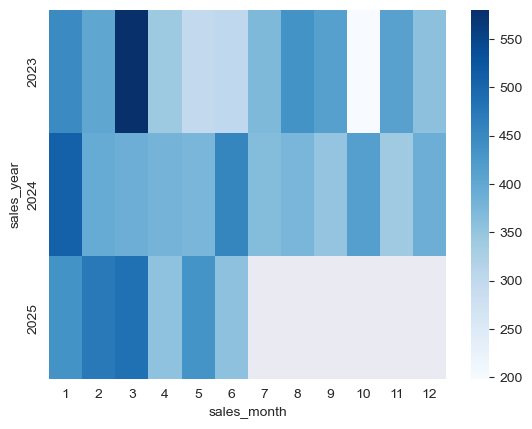

In [88]:
sns.heatmap(yearly_data,cmap='Blues')

Sales show clear seasonality with strong performance in Q1.

In [89]:
# Are returns increasing over time?
yearly_returns = data.groupby(['sales_year','sales_month'])[['Returned']].sum()

In [90]:
yearly_returns_data = yearly_returns.unstack()

In [91]:
yearly_returns_data.columns = yearly_returns_data.columns.droplevel(0)

In [92]:
yearly_returns_data

sales_month,1,2,3,4,5,6,7,8,9,10,11,12
sales_year,,,,,,,,,,,,
2023,8.0,7.0,14.0,10.0,11.0,7.0,9.0,9.0,9.0,6.0,7.0,8.0
2024,5.0,11.0,8.0,7.0,13.0,13.0,10.0,12.0,7.0,10.0,10.0,8.0
2025,8.0,9.0,13.0,9.0,14.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN


<AxesSubplot:xlabel='sales_month', ylabel='sales_year'>

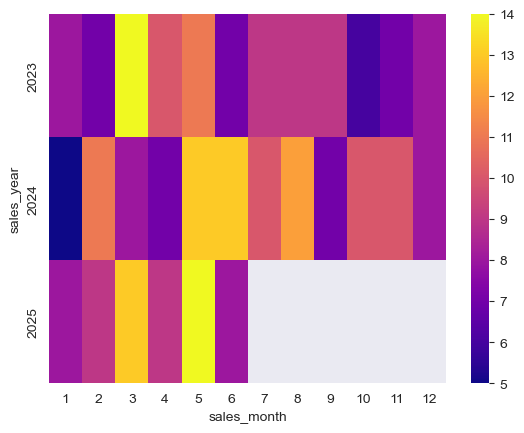

In [93]:
sns.heatmap(yearly_returns_data,cmap='plasma')

Returns fluctuate over time without a consistent increasing trend.

## 📊 Final Insights

Sales show clear seasonality, with peak performance in the first quarter (January to March), followed by a decline during mid-year (July to October), and a slight recovery toward the end of the year. Returns fluctuate over time without a consistent increasing trend.

## Business Recommendations

### 1. Prioritize High-Performing Products:
Allocate more inventory, marketing budget, and promotions to top revenue-generating products like Tablet and Laptop to maximize profitability.

### 2. Reduce Returns in High-Risk Regions:
Investigate and address causes of high returns in South and West regions by improving logistics, product quality checks, and customer expectation alignment.

### 3. Control Wholesale Return Risk:
Implement stricter return policies, bulk order validation, and quality assurance for wholesale customers to reduce high return volumes.

### 4. Shift from Discounts to Value-Based Offers:
Minimize reliance on discounts and focus on value-driven strategies such as bundles, product quality, and customer experience, as discounts show limited impact on sales.

### 5. Expand Free Shipping Strategy:
Leverage free shipping (FREESHIP) more aggressively, as it has proven to drive higher revenue compared to traditional discount promotions.

### 6. Optimize Shipping Cost Strategy:
Maintain mid-range shipping costs, as they generate higher revenue, avoiding extremes that may negatively impact customer purchasing behavior.

### 7. Implement Return Reduction Strategies:
Improve product descriptions, set clear expectations, and enhance quality checks to reduce the high overall return rate (~25%).

### 8. Promote Digital Payment Adoption:
Encourage online payments through incentives, as they are associated with higher revenue and relatively lower return rates compared to cash transactions.

### 9. Align Strategy with Seasonal Demand:
Plan inventory, staffing, and marketing campaigns around peak sales periods (Q1) to fully capitalize on seasonal demand patterns.

## Conclusion

This exploratory data analysis highlights key factors influencing retail sales performance, including product demand, regional trends, customer behavior, and operational efficiency. The analysis reveals that sales are driven by a combination of product popularity, effective promotions such as free shipping, and seasonal demand patterns. While wholesale customers and certain regions contribute significantly to revenue, they also exhibit higher return rates, indicating areas for operational improvement. Additionally, pricing strategies such as discounts show limited impact on sales, whereas moderate shipping costs and digital payment methods play a more favorable role. Overall, the insights derived from this analysis can help businesses optimize their strategies, improve customer satisfaction, and enhance overall profitability.